# Preliminary Data Analytic Pipeline for the HW3 Post
Provide a coded solution for each area below.  Where appropriate show output and explanations/insights.  Make sure it runs properly.
You will need to install the libraries below if required just

!pip install < lib >
* [pandas](https://pandas.pydata.org/)  
   * [Pandas Tutorials](https://pandas.pydata.org/docs/getting_started/intro_tutorials/index.html) 
   * [Pandas Example](https://towardsdatascience.com/30-examples-to-master-pandas-f8a2da751fa4)
* [numpy](https://numpy.org/) 
   * [Numpy Examples](https://numpy.org/doc/stable/user/quickstart.html)
* [scikit-learn with Examples](https://scikit-learn.org/stable) 
* [ydata_profiling](https://ydata-profiling.ydata.ai/docs/master/pages/getting_started/overview.html)

In [ ]:
# !pip install pandas 
# !pip install numpy 
# !pip install scikit-learn 
# !pip install ydata-profiling
!pip install pgeocode

In [1]:
import pandas as pd
import numpy as np
import sklearn
from ydata_profiling import ProfileReport
from ydata_profiling.utils.cache import cache_file
from pathlib import Path
from copy import deepcopy
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Allow full view of DataFrames and Series
pd.set_option('display.max_columns', None)  # None or 1000
# pd.set_option('display.max_rows', None)  # or 1000
pd.set_option('display.max_colwidth', None)  # or 199

## Data Integration
Use the fraud data set introduced earlier in the course

In [3]:
# data integration
df = pd.read_csv('./transactions-1.csv')

In [4]:
df

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,sex,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,Michael,Olson,M,558 Michael Estates,Luray,MO,63453,40.4931,-91.8912,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0
1852390,1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,Lake Jackson,TX,77566,29.0393,-95.4401,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0
1852391,1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,Burbank,WA,99323,46.1966,-118.9017,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0
1852392,1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,Eric,Preston,M,7020 Doyle Stream Apt. 951,Mesa,ID,83643,44.6255,-116.4493,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0


**The code to extract perfect correlations with *fraud=1*.**

In [25]:
def get_hicors(cols):
    for col in cols:
        print('{}'.format(col))
        pd.set_option('display.max_rows', None)  # or 1000
        print(len(df['{}'.format(col)].unique()))
        valcors = (df.loc[df['is_fraud'] == 1, '{}'.format(col)].value_counts() /\
               df['{}'.format(col)].value_counts()).sort_values(ascending=False)
        values = []
        for value, cor in valcors.items():
            if cor == 1.0:
                values.append(value)
        print(len(values))
        print(values)
        print()
        pd.set_option('display.max_rows', 10)  # or 1000

In [26]:
get_hicors(['zip', 'city', 'state', 'job'])

zip
985
88
['10018', '4032', '37307', '37411', '37683', '37887', '38668', '38915', '39562', '40502', '16041', '41101', '43723', '46060', '46510', '47842', '48054', '48436', '35896', '35211', '33762', '32065', '16428', '18446', '19947', '21657', '22124', '22204', '23117', '23523', '27051', '28033', '28119', '28412', '28530', '29129', '29180', '52658', '53045', '53559', '77027', '78208', '78644', '80019', '85201', '87417', '89109', '90240', '93427', '94508', '95688', '97850', '98105', '98118', '99116', '99747', '77038', '76048', '54980', '75246', '55040', '56367', '61364', '62896', '63966', '64080', '65745', '66958', '67346', '68375', '70065', '70447', '72135', '73044', '74108', '16214', '99921', '12207', '10954', '14141', '11763', '11747', '12508', '10553', '13795', '11944', '14532', '10533']

city
906
70
['Rice', 'Norfolk', 'Ridge Spring', 'East China', 'Queen Anne', 'Waukau', 'Pleasant Hill', 'Freeport', 'Phelps', 'Beacon', 'Gaines', 'Granbury', 'Greenport', 'Grenola', 'Brookfield', '

**The code to examine the distribution of lat/lon distances between merchant/vendor and customer.**

In [13]:
df['dist'] = np.sqrt(np.power(np.subtract(df['merch_lat'], df['lat']), 2) + np.power(np.subtract(df['merch_long'], df['long']), 2))

In [14]:
f1dist = df.loc[df['is_fraud'] == 1, 'dist'].to_numpy().reshape(-1, 1)
f0dist = df.loc[df['is_fraud'] == 0, 'dist'].to_numpy().reshape(-1, 1)

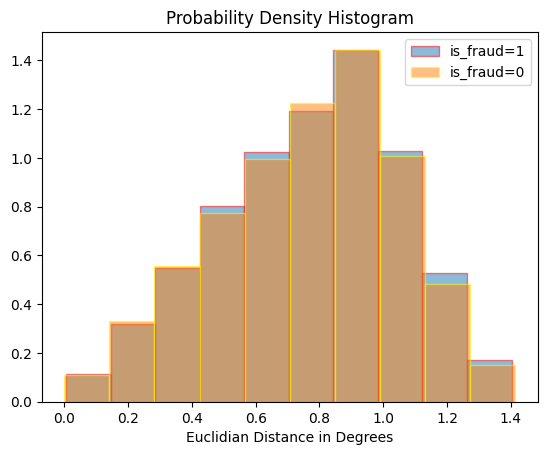

In [24]:
plt.hist(f1dist, label = 'is_fraud=1', density=True, alpha=0.5, edgecolor='red')
plt.hist(f0dist, label = 'is_fraud=0', density=True, alpha=0.5, edgecolor='yellow')
plt.title('Probability Density Histogram')
plt.xlabel('Euclidian Distance in Degrees')
plt.legend()
plt.show()

**The code to examine the distribution of fraud vs no-fraud.**/

In [11]:
df['is_fraud'].value_counts()

0    1842743
1       9651
Name: is_fraud, dtype: int64